In [40]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np

In [41]:
# Load in the terms

path = '//work/scratch-pw5/hjwood/p_budget_terms/eqn_terms'

# 1. CORIOLIS TERMS
fv_file = f"{path}/fv_MAM_saf.nc"
fv_ds = xr.open_dataset(fv_file)

cort2_file = f"{path}/coriolist2_MAM_saf.nc"
cort2_ds = xr.open_dataset(cort2_file)

# 2. ADVECTION TERMS
dudx_file = f"{path}/u_dudx_MAM_saf.nc"
dudx_ds = xr.open_dataset(dudx_file)

dudy_file = f"{path}/v_dudy_MAM_saf.nc"
dudy_ds = xr.open_dataset(dudy_file)

dudz_file = f"{path}/wdu_dz_MAM_saf.nc"
dudz_ds = xr.open_dataset(dudz_file)

# 3. EDDY TERMS
duvdy_file = f"{path}/duv_dy_MAM_saf.nc"
duvdy_ds = xr.open_dataset(duvdy_file)

dusqdx_file = f"{path}/dusq_dx_MAM_saf.nc"
dusqdx_ds = xr.open_dataset(dusqdx_file)

In [42]:
# Make general coriolis, mean flow, and eddy flow terms
coriolis = fv_ds.fv + cort2_ds.coriolis_t2

advection = dudx_ds.u_dudx + dudy_ds.v_dudy + dudz_ds.wdu_dz

eddy = duvdy_ds.duv_dy + dusqdx_ds.dusq_dx

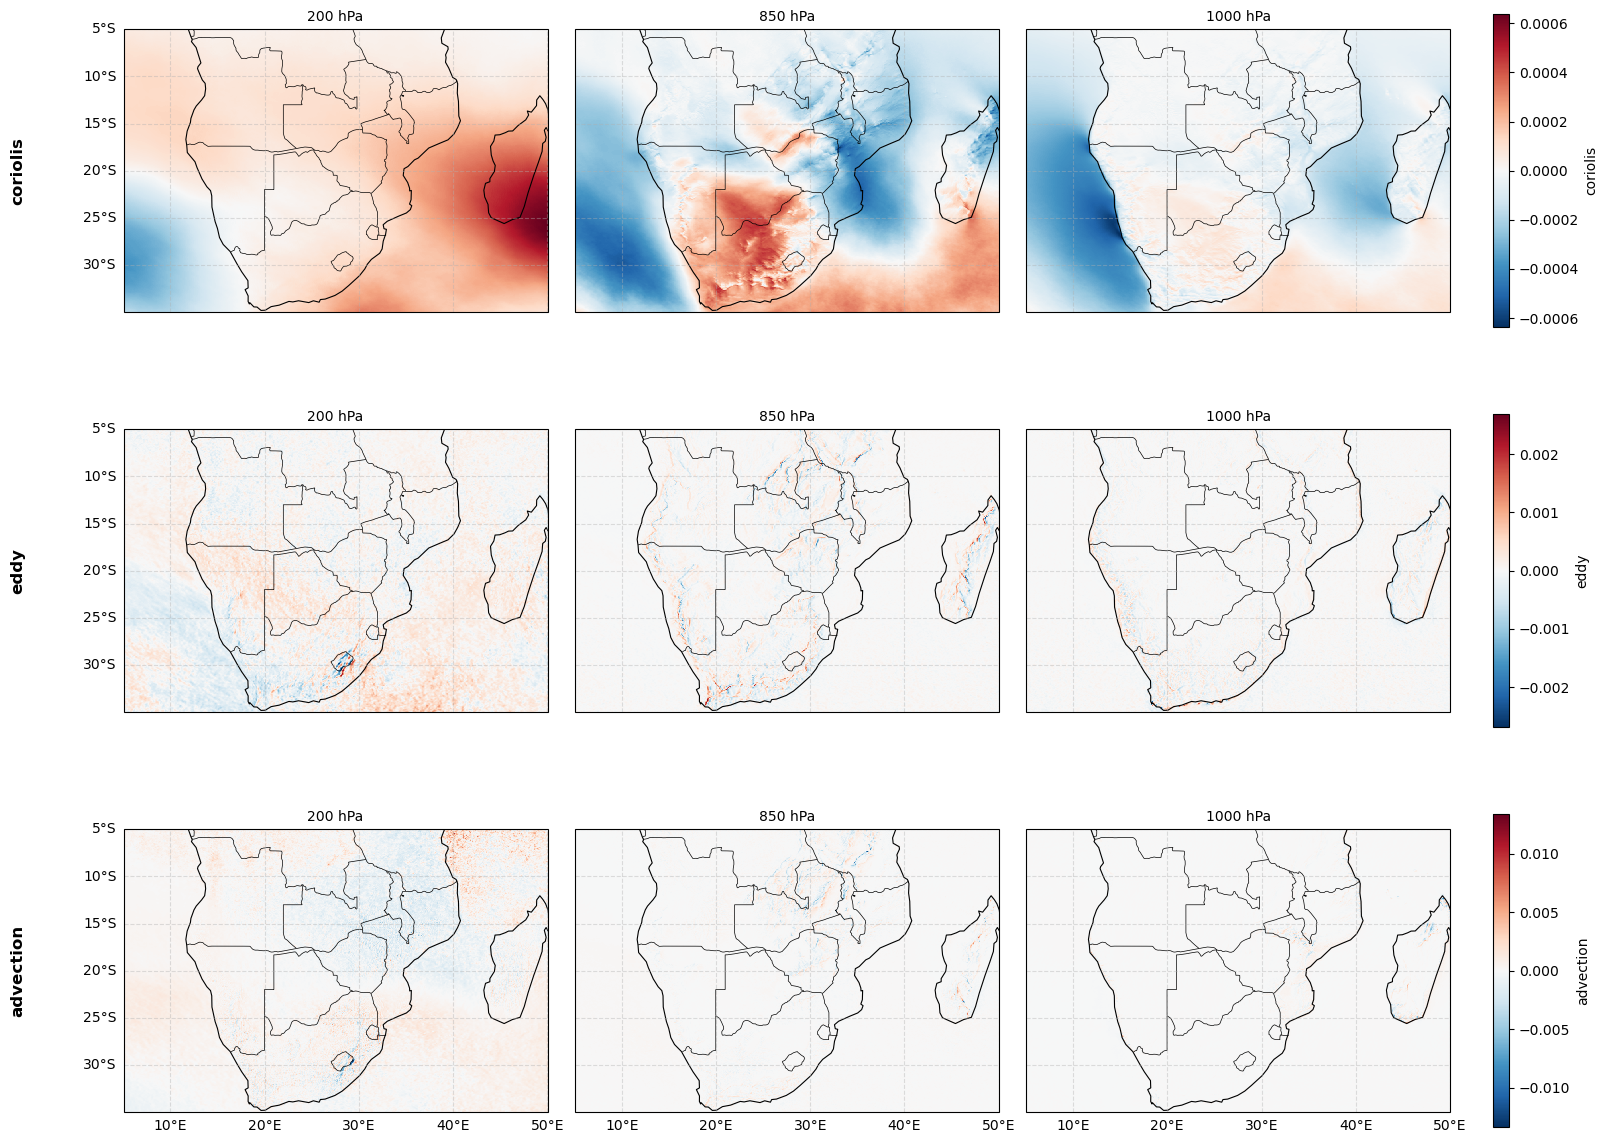

In [43]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data = {
    'coriolis': coriolis,
    'eddy': eddy,
    'advection': advection,
}

pressure_levels = [200, 850, 1000]
variables = ['coriolis', 'eddy', 'advection']

fig, axes = plt.subplots(
    nrows=len(variables),          # each variable gets a row
    ncols=len(pressure_levels),    # each pressure level gets a column
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

for i, var in enumerate(variables):

    # Store one image handle per variable for separate colorbars
    ims = []

    for j, plev in enumerate(pressure_levels):

        ax = axes[i, j]

        da = data[var].sel(pressure=plev, method='nearest')

        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap='RdBu_r',
            add_colorbar=False
        )

        ims.append(im)

        # Map features
        ax.coastlines(resolution='110m', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        # Gridlines
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)

        gl.top_labels = False
        gl.right_labels = False

        # Reduce clutter
        if j != 0:
            gl.left_labels = False

        if i != len(variables) - 1:
            gl.bottom_labels = False

        ax.set_title(f'{plev} hPa', fontsize=10)

    # Add one colorbar for the whole row
    cbar = fig.colorbar(
        ims[-1],
        ax=axes[i, :],
        orientation='vertical',
        shrink=0.8,
        pad=0.02
    )

    cbar.set_label(var)

    # Row label on left side
    axes[i, 0].text(
        -0.25, 0.5,
        var,
        transform=axes[i, 0].transAxes,
        rotation=90,
        va='center',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )
# plt.savefig("pbudget_MAM_GAL_SAfrica.png")
plt.show()

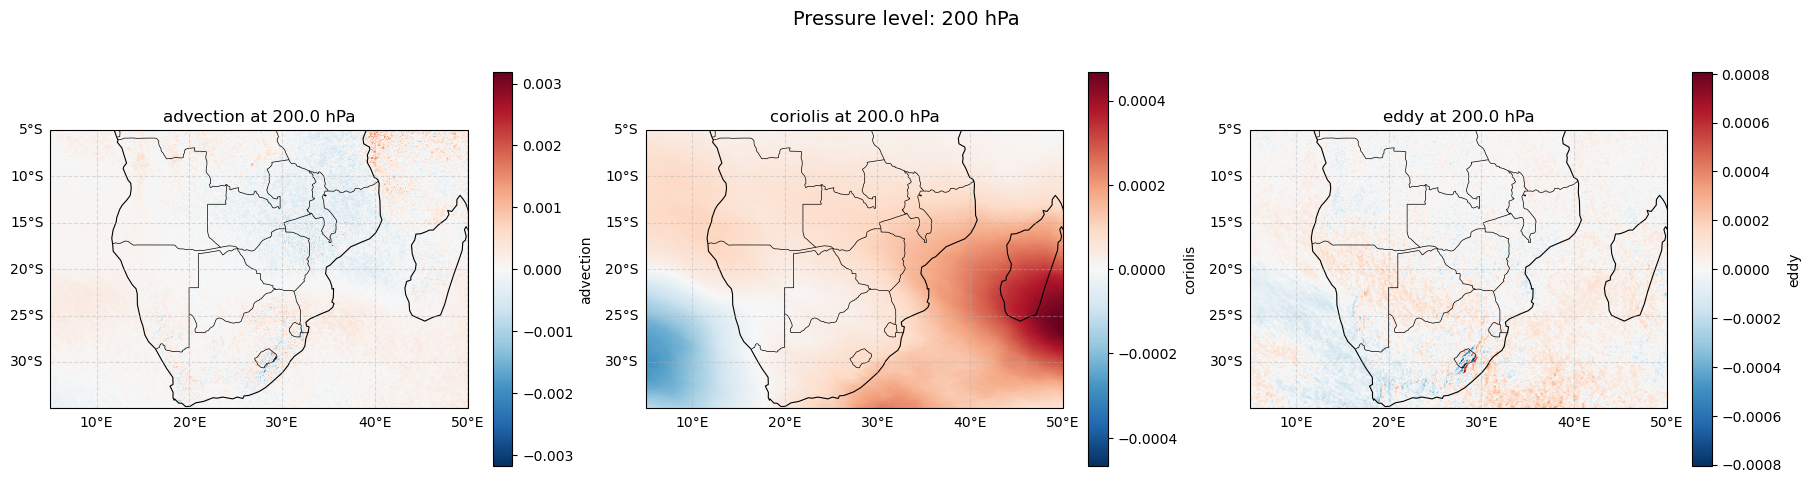

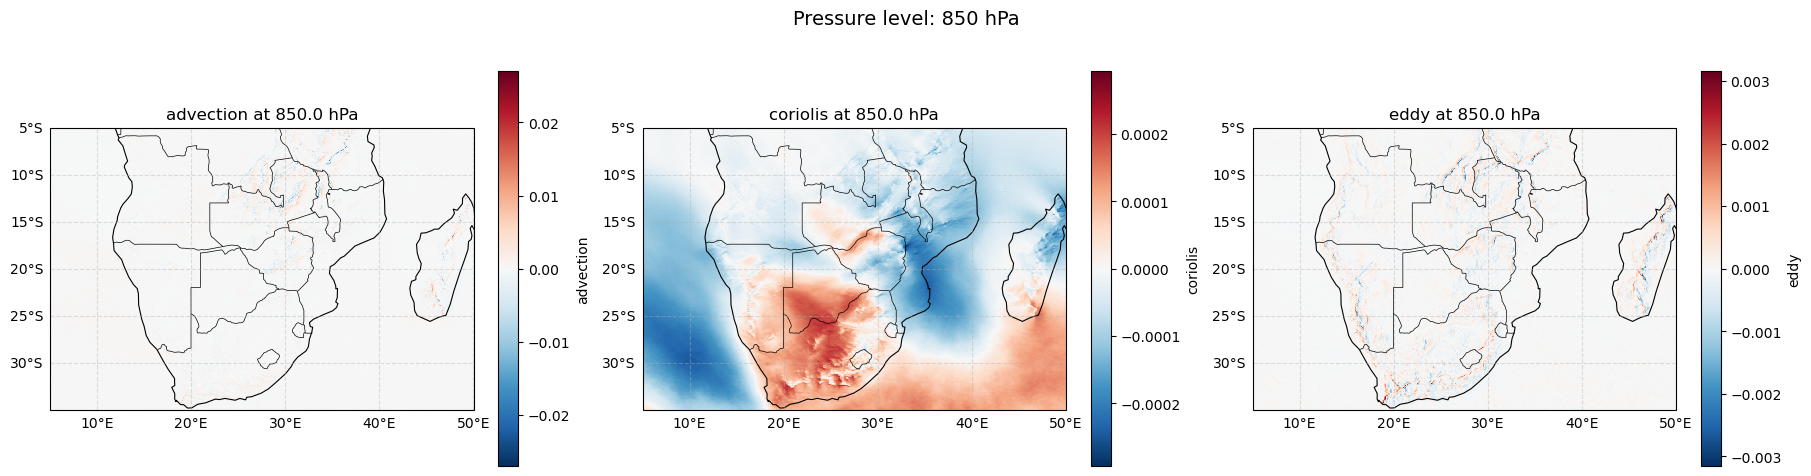

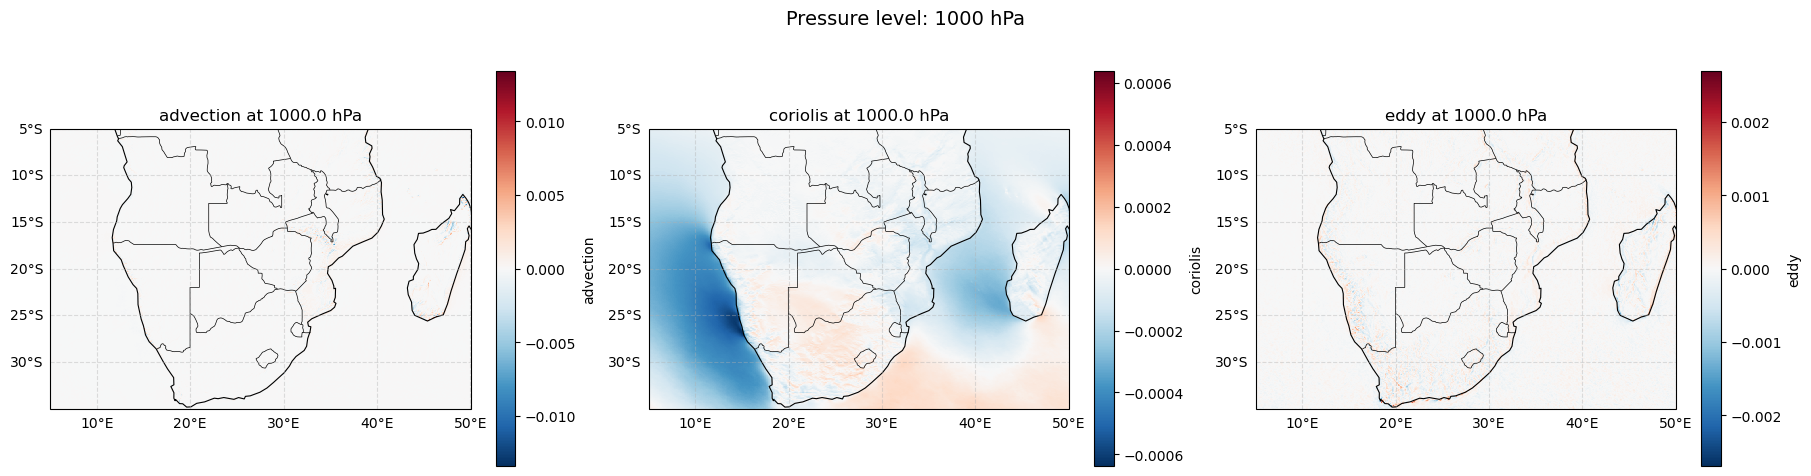

In [44]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data = {
    'advection': advection,
    'coriolis': coriolis,
    'eddy': eddy,
}

pressure_levels = [200, 850, 1000]
variables = ['advection', 'coriolis', 'eddy']

for plev in pressure_levels:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True
    )

    for ax, var in zip(axes, variables):
        da = data[var].sel(pressure=plev, method='nearest')

        vmax = np.nanmax(np.abs(da.values))
        vmin = vmax/5

        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap='RdBu_r',
            vmin=-vmax,
            vmax=vmax,
            add_colorbar=False
        )

        ax.coastlines(resolution='110m', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
        gl.top_labels = False
        gl.right_labels = False

        ax.set_title(f'{var} at {float(da.pressure.values)} hPa')

        cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label(var)

    fig.suptitle(f'Pressure level: {plev} hPa', fontsize=14)
    plt.show()